# Truck Charging Profile Analysis & Generation

Analyze AI Sweden truck charging data and build a full 2024 hourly profile.

**Data source:** 40% electrification scenario (~24,000 heavy duty BEVs)

**Process:**
1. Load bi-monthly data with weekday/weekend and hourly patterns
2. Aggregate away hex (geography) dimension
3. Analyze seasonal variation
4. Build full 8784-hour profile for 2024
5. Validate and export

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

DATA_PATH = Path.cwd()
FILE_40PCT = 'export_aisweden_monthsPerGroup_2_dayAgg_weekday_opp_both_40pct(export_aisweden_monthsPerGroup_).csv'

## 1. Load Data

In [2]:
# Load the 40% scenario data
# File has entire rows wrapped in quotes - need to handle this
import io

with open(DATA_PATH / FILE_40PCT, 'r') as f:
    # Remove surrounding quotes from each line
    cleaned = '\n'.join(line.strip().strip('"') for line in f)

df = pd.read_csv(io.StringIO(cleaned))

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nUnique hex: {df['hex'].nunique()}")
print(f"Unique month periods: {df['month'].unique()}")
print(f"Unique weekday: {df['weekday'].unique()}")
print(f"Hours: {df['hour'].min()} - {df['hour'].max()}")

df.head(10)

Shape: (313080, 6)

Columns: ['hex', 'month', 'weekday', 'hour', 'fast_charging_power_mw_95_percentile', 'total_power_mw_95_percentile']

Unique hex: 1556
Unique month periods: ['January-February' 'July-August' 'March-April' 'May-June'
 'November-December' 'September-October']
Unique weekday: ['weekday' 'weekend']
Hours: 0 - 23


,hex,month,weekday,hour,fast_charging_power_mw_95_percentile,total_power_mw_95_percentile
0,85081047fffffff,January-February,weekday,0,0.0,0.0
1,85081047fffffff,January-February,weekday,1,0.0,0.0
2,85081047fffffff,January-February,weekday,2,0.0,0.0
3,85081047fffffff,January-February,weekday,3,0.0,0.0
4,85081047fffffff,January-February,weekday,4,0.0,0.0
5,85081047fffffff,January-February,weekday,5,0.0,0.0
6,85081047fffffff,January-February,weekday,6,0.0,0.0
7,85081047fffffff,January-February,weekday,7,0.0,0.0
8,85081047fffffff,January-February,weekday,8,0.0,0.0
9,85081047fffffff,January-February,weekday,9,0.0,0.0


## 2. Aggregate Away Hex (Sum Over All Geographies)

In [3]:
# Sum over all hexes, keeping month, weekday, hour
df_agg = df.groupby(['month', 'weekday', 'hour']).agg({
    'fast_charging_power_mw_95_percentile': 'sum',
    'total_power_mw_95_percentile': 'sum'
}).reset_index()

print(f"Aggregated shape: {df_agg.shape}")
print(f"Expected: 6 months × 2 weekday/weekend × 24 hours = {6 * 2 * 24} rows")

df_agg.head(30)

Aggregated shape: (288, 5)
Expected: 6 months × 2 weekday/weekend × 24 hours = 288 rows


,month,weekday,hour,fast_charging_power_mw_95_percentile,total_power_mw_95_percentile
0,January-February,weekday,0,171.0,999.0
1,January-February,weekday,1,143.7,948.6
2,January-February,weekday,2,128.9,863.8
3,January-February,weekday,3,139.8,758.7
4,January-February,weekday,4,151.0,628.9
5,January-February,weekday,5,165.9,492.8
6,January-February,weekday,6,241.1,421.7
7,January-February,weekday,7,374.4,451.8
8,January-February,weekday,8,503.2,547.0
9,January-February,weekday,9,788.7,790.6


## 3. Normalize (Divide by Total)

In [4]:
# Normalize total_power to sum to 1.0
total_sum = df_agg['total_power_mw_95_percentile'].sum()
df_agg['normalized'] = df_agg['total_power_mw_95_percentile'] / total_sum

print(f"Total power before normalization: {total_sum:.2f} MW")
print(f"Sum after normalization: {df_agg['normalized'].sum():.6f}")

df_agg.head()

Total power before normalization: 171122.80 MW
Sum after normalization: 1.000000


,month,weekday,hour,fast_charging_power_mw_95_percentile,total_power_mw_95_percentile,normalized
0,January-February,weekday,0,171.0,999.0,0.005838
1,January-February,weekday,1,143.7,948.6,0.005543
2,January-February,weekday,2,128.9,863.8,0.005048
3,January-February,weekday,3,139.8,758.7,0.004434
4,January-February,weekday,4,151.0,628.9,0.003675


## 4. Analyze Seasonal Variation

In [5]:
# Order the months properly
month_order = [
    'January-February',
    'March-April', 
    'May-June',
    'July-August',
    'September-October',
    'November-December'
]

# Total by month period
monthly_totals = df_agg.groupby('month')['normalized'].sum()
monthly_totals = monthly_totals.reindex(month_order)

print("Normalized totals by 2-month period:")
print(monthly_totals)
print(f"\nSum: {monthly_totals.sum():.6f}")

# Expected if flat: 1/6 = 0.1667 per period
print(f"\nExpected if flat: {1/6:.4f}")
print(f"\nRatio (max/min): {monthly_totals.max() / monthly_totals.min():.2f}x")

Normalized totals by 2-month period:
month
January-February     0.161526
March-April          0.166206
May-June             0.170153
July-August          0.154830
September-October    0.177823
November-December    0.169464
Name: normalized, dtype: float64

Sum: 1.000000

Expected if flat: 0.1667

Ratio (max/min): 1.15x


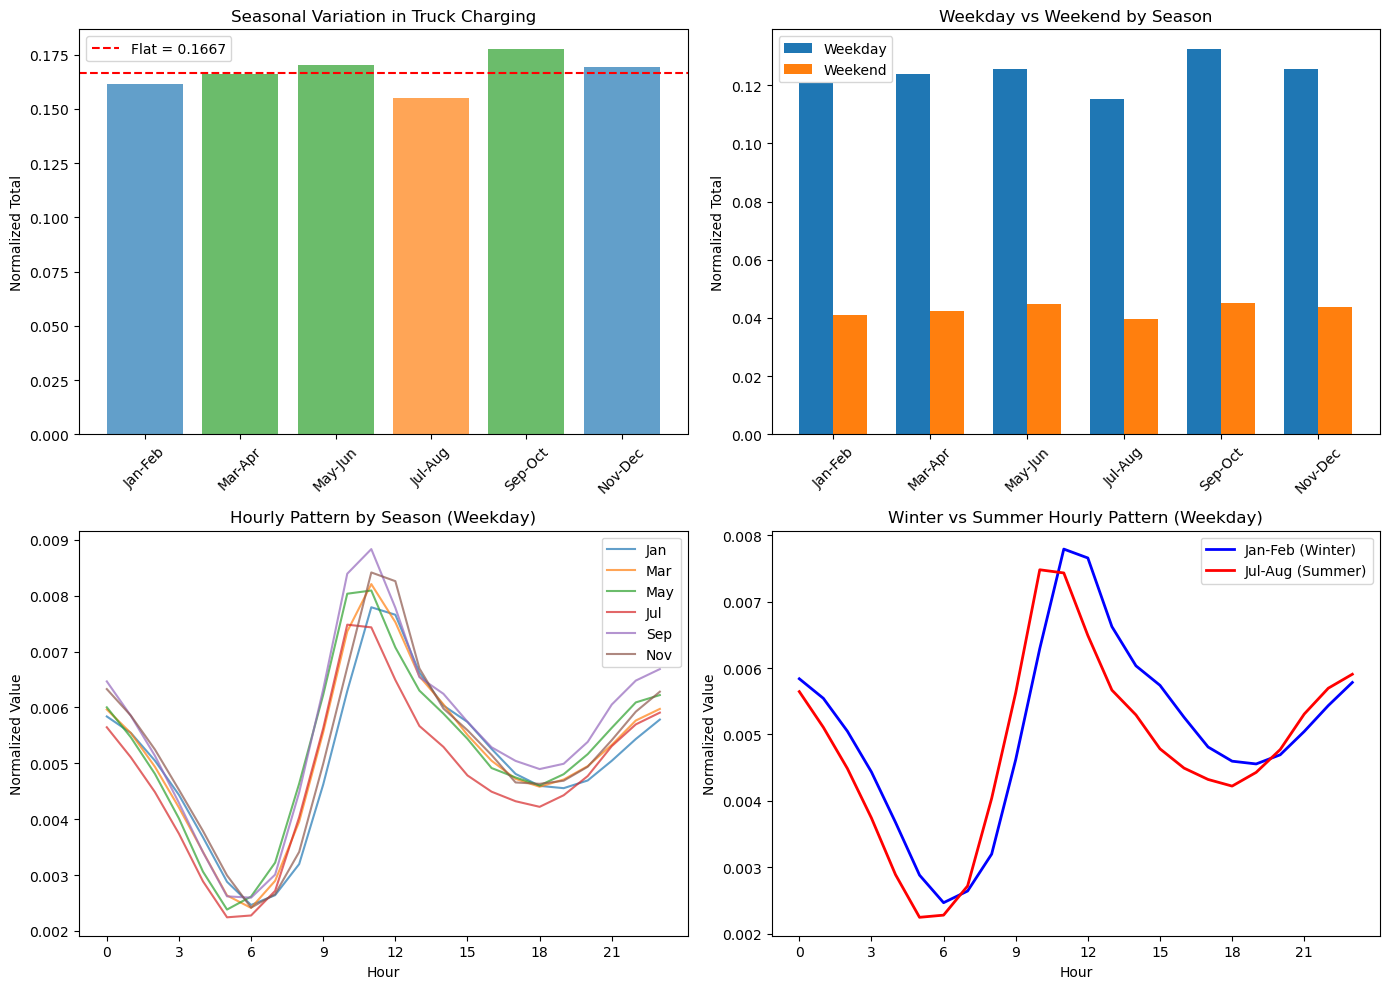

In [6]:
# Visualize seasonal variation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Monthly totals
ax1 = axes[0, 0]
colors = ['#1f77b4', '#2ca02c', '#2ca02c', '#ff7f0e', '#2ca02c', '#1f77b4']  # Winter blue, summer orange
bars = ax1.bar(range(6), monthly_totals.values, color=colors, alpha=0.7)
ax1.axhline(y=1/6, color='red', linestyle='--', label=f'Flat = {1/6:.4f}')
ax1.set_xticks(range(6))
ax1.set_xticklabels(['Jan-Feb', 'Mar-Apr', 'May-Jun', 'Jul-Aug', 'Sep-Oct', 'Nov-Dec'], rotation=45)
ax1.set_ylabel('Normalized Total')
ax1.set_title('Seasonal Variation in Truck Charging')
ax1.legend()

# 2. Weekday vs Weekend by season
ax2 = axes[0, 1]
weekday_monthly = df_agg[df_agg['weekday'] == 'weekday'].groupby('month')['normalized'].sum().reindex(month_order)
weekend_monthly = df_agg[df_agg['weekday'] == 'weekend'].groupby('month')['normalized'].sum().reindex(month_order)

x = np.arange(6)
width = 0.35
ax2.bar(x - width/2, weekday_monthly.values, width, label='Weekday', color='#1f77b4')
ax2.bar(x + width/2, weekend_monthly.values, width, label='Weekend', color='#ff7f0e')
ax2.set_xticks(x)
ax2.set_xticklabels(['Jan-Feb', 'Mar-Apr', 'May-Jun', 'Jul-Aug', 'Sep-Oct', 'Nov-Dec'], rotation=45)
ax2.set_ylabel('Normalized Total')
ax2.set_title('Weekday vs Weekend by Season')
ax2.legend()

# 3. Hourly pattern by season (weekday only)
ax3 = axes[1, 0]
for month in month_order:
    hourly = df_agg[(df_agg['month'] == month) & (df_agg['weekday'] == 'weekday')].set_index('hour')['normalized']
    ax3.plot(hourly.index, hourly.values, label=month[:3], alpha=0.7)
ax3.set_xlabel('Hour')
ax3.set_ylabel('Normalized Value')
ax3.set_title('Hourly Pattern by Season (Weekday)')
ax3.legend()
ax3.set_xticks(range(0, 24, 3))

# 4. Compare Jan-Feb vs Jul-Aug
ax4 = axes[1, 1]
jan_feb = df_agg[(df_agg['month'] == 'January-February') & (df_agg['weekday'] == 'weekday')].set_index('hour')['normalized']
jul_aug = df_agg[(df_agg['month'] == 'July-August') & (df_agg['weekday'] == 'weekday')].set_index('hour')['normalized']
ax4.plot(jan_feb.index, jan_feb.values, 'b-', linewidth=2, label='Jan-Feb (Winter)')
ax4.plot(jul_aug.index, jul_aug.values, 'r-', linewidth=2, label='Jul-Aug (Summer)')
ax4.set_xlabel('Hour')
ax4.set_ylabel('Normalized Value')
ax4.set_title('Winter vs Summer Hourly Pattern (Weekday)')
ax4.legend()
ax4.set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.show()

In [7]:
# Calculate seasonal multipliers (relative to mean)
mean_monthly = monthly_totals.mean()
seasonal_multipliers = monthly_totals / mean_monthly

print("Seasonal multipliers (relative to mean):")
print(seasonal_multipliers.round(3))
print(f"\nMean: {mean_monthly:.4f}")
print(f"Sum of multipliers: {seasonal_multipliers.sum():.2f} (should be 6.0)")
print(f"\nSeasonal amplitude: {(seasonal_multipliers.max() - 1) * 100:.1f}% to {(seasonal_multipliers.min() - 1) * 100:.1f}%")

Seasonal multipliers (relative to mean):
month
January-February     0.969
March-April          0.997
May-June             1.021
July-August          0.929
September-October    1.067
November-December    1.017
Name: normalized, dtype: float64

Mean: 0.1667
Sum of multipliers: 6.00 (should be 6.0)

Seasonal amplitude: 6.7% to -7.1%


## 5. Summary

In [8]:
# Summary statistics
print("=" * 60)
print("TRUCK CHARGING SEASONAL ANALYSIS SUMMARY")
print("=" * 60)

print(f"\nData: 40% electrification scenario (~24,000 trucks)")
print(f"Hexes aggregated: {df['hex'].nunique()}")

print(f"\n--- Seasonal Variation ---")
print(f"Max/Min ratio: {monthly_totals.max() / monthly_totals.min():.2f}x")
print(f"Peak period: {monthly_totals.idxmax()}")
print(f"Lowest period: {monthly_totals.idxmin()}")

print(f"\n--- Weekday/Weekend ---")
weekday_total = df_agg[df_agg['weekday'] == 'weekday']['normalized'].sum()
weekend_total = df_agg[df_agg['weekday'] == 'weekend']['normalized'].sum()
print(f"Weekday total: {weekday_total:.4f} ({weekday_total*100:.1f}%)")
print(f"Weekend total: {weekend_total:.4f} ({weekend_total*100:.1f}%)")
print(f"Weekday/Weekend ratio: {weekday_total/weekend_total:.2f}x")

print(f"\n--- Recommendation ---")
if monthly_totals.max() / monthly_totals.min() > 1.1:
    print("Seasonal variation detected - consider using seasonal multipliers")
else:
    print("Minimal seasonal variation - flat profile may be sufficient")

TRUCK CHARGING SEASONAL ANALYSIS SUMMARY

Data: 40% electrification scenario (~24,000 trucks)
Hexes aggregated: 1556

--- Seasonal Variation ---
Max/Min ratio: 1.15x
Peak period: September-October
Lowest period: July-August

--- Weekday/Weekend ---
Weekday total: 0.7430 (74.3%)
Weekend total: 0.2570 (25.7%)
Weekday/Weekend ratio: 2.89x

--- Recommendation ---
Seasonal variation detected - consider using seasonal multipliers


## 6. Build Full 2024 Profile

Create 8784 hours (leap year) by mapping each hour to its bi-monthly period and weekday/weekend pattern.

In [9]:
# Create datetime index for all hours of 2024
hours_2024 = pd.date_range('2024-01-01', '2024-12-31 23:00:00', freq='h')
print(f"Hours in 2024: {len(hours_2024)} (expected 8784 for leap year)")

# Create dataframe with hour metadata
df_2024 = pd.DataFrame({'timestamp': hours_2024})
df_2024['hour'] = df_2024['timestamp'].dt.hour
df_2024['month_num'] = df_2024['timestamp'].dt.month
df_2024['dayofweek'] = df_2024['timestamp'].dt.dayofweek  # 0=Monday, 6=Sunday

# Map to bi-monthly periods
def get_bimonthly_period(month):
    period_map = {
        1: 'January-February', 2: 'January-February',
        3: 'March-April', 4: 'March-April',
        5: 'May-June', 6: 'May-June',
        7: 'July-August', 8: 'July-August',
        9: 'September-October', 10: 'September-October',
        11: 'November-December', 12: 'November-December'
    }
    return period_map[month]

df_2024['month'] = df_2024['month_num'].apply(get_bimonthly_period)

# Map to weekday/weekend (Mon-Fri = weekday, Sat-Sun = weekend)
df_2024['weekday'] = df_2024['dayofweek'].apply(lambda x: 'weekday' if x < 5 else 'weekend')

print(f"\nPeriod distribution:")
print(df_2024.groupby('month')['timestamp'].count().reindex(month_order))

print(f"\nWeekday/Weekend distribution:")
print(df_2024.groupby('weekday')['timestamp'].count())

Hours in 2024: 8784 (expected 8784 for leap year)

Period distribution:
month
January-February     1440
March-April          1464
May-June             1464
July-August          1488
September-October    1464
November-December    1464
Name: timestamp, dtype: int64

Weekday/Weekend distribution:
weekday
weekday    6288
weekend    2496
Name: timestamp, dtype: int64


In [10]:
# Create lookup table from aggregated data (month, weekday, hour -> power value)
# Use total_power_mw_95_percentile as the base pattern
lookup = df_agg.set_index(['month', 'weekday', 'hour'])['total_power_mw_95_percentile']

# Look up value for each hour in 2024
df_2024['power'] = df_2024.apply(
    lambda row: lookup.loc[(row['month'], row['weekday'], row['hour'])],
    axis=1
)

# Normalize so sum = 1.0
df_2024['normalized'] = df_2024['power'] / df_2024['power'].sum()

print(f"Profile statistics:")
print(f"  Sum: {df_2024['normalized'].sum():.6f}")
print(f"  Min: {df_2024['normalized'].min():.8f}")
print(f"  Max: {df_2024['normalized'].max():.8f}")
print(f"  Mean: {df_2024['normalized'].mean():.8f}")

df_2024.head(30)

Profile statistics:
  Sum: 1.000000
  Min: 0.00003618
  Max: 0.00023941
  Mean: 0.00011384


,timestamp,hour,month_num,dayofweek,month,weekday,power,normalized
0,2024-01-01 00:00:00,0,1,0,January-February,weekday,999.0,0.000158
1,2024-01-01 01:00:00,1,1,0,January-February,weekday,948.6,0.000150
2,2024-01-01 02:00:00,2,1,0,January-February,weekday,863.8,0.000137
3,2024-01-01 03:00:00,3,1,0,January-February,weekday,758.7,0.000120
4,2024-01-01 04:00:00,4,1,0,January-February,weekday,628.9,0.000100
5,2024-01-01 05:00:00,5,1,0,January-February,weekday,492.8,0.000078
6,2024-01-01 06:00:00,6,1,0,January-February,weekday,421.7,0.000067
7,2024-01-01 07:00:00,7,1,0,January-February,weekday,451.8,0.000072
8,2024-01-01 08:00:00,8,1,0,January-February,weekday,547.0,0.000087
9,2024-01-01 09:00:00,9,1,0,January-February,weekday,790.6,0.000125


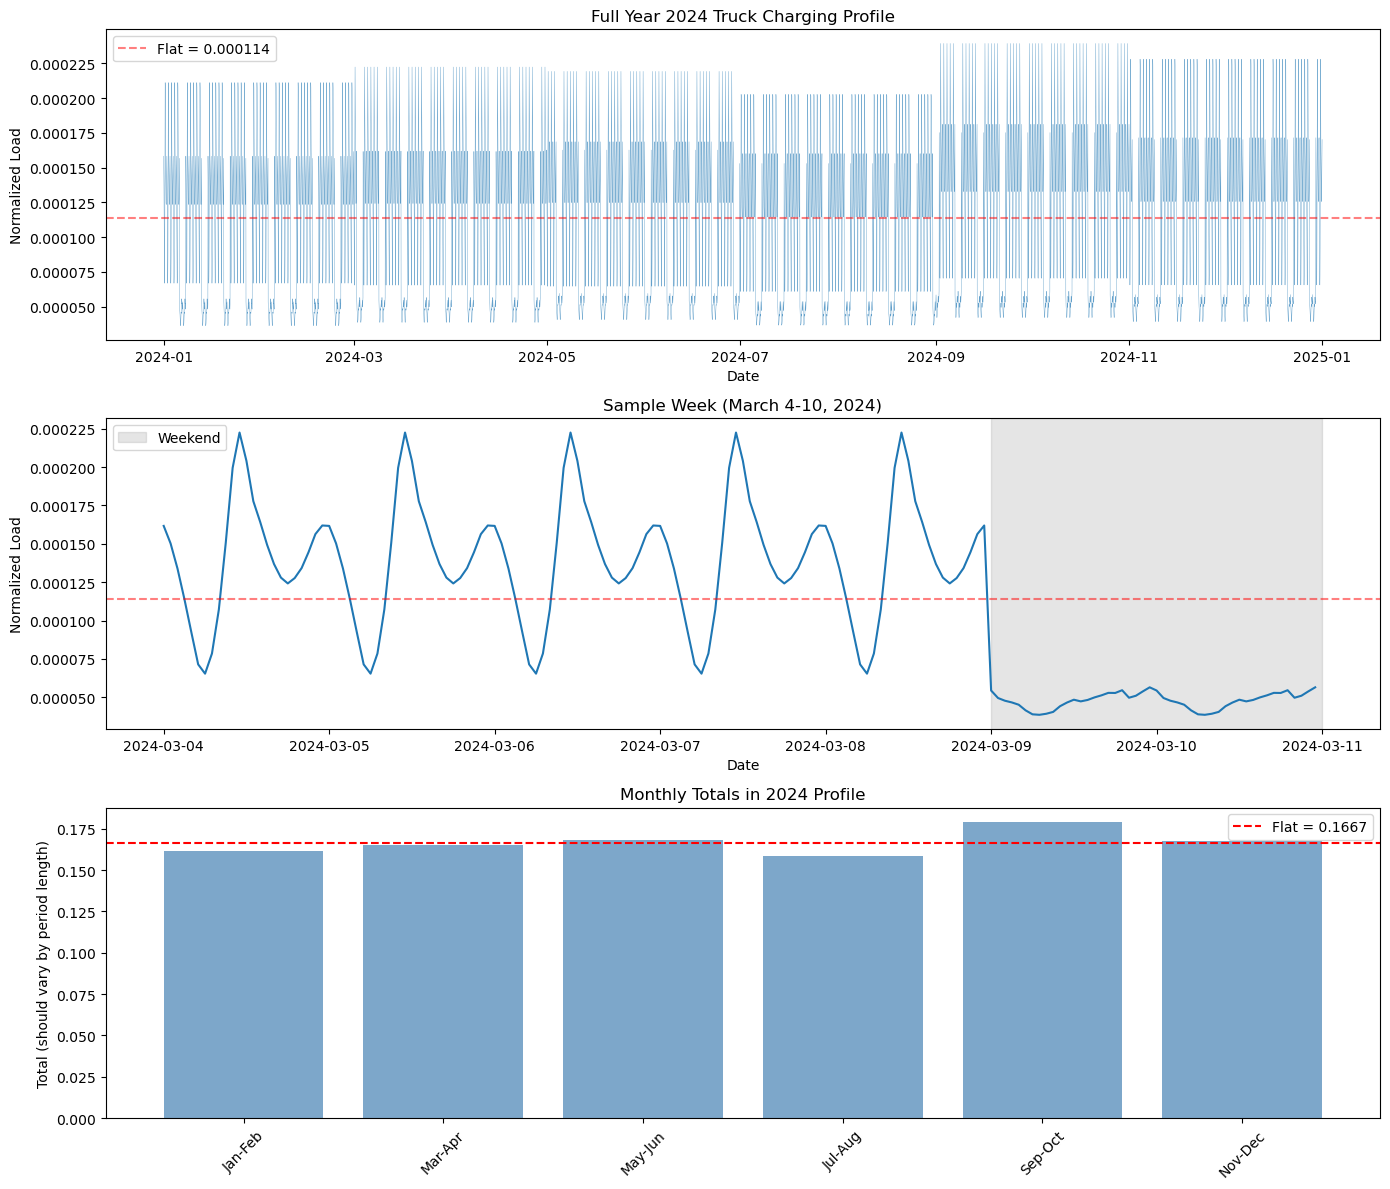


Monthly totals in 2024 profile:
month
January-February     0.1616
March-April          0.1650
May-June             0.1680
July-August          0.1587
September-October    0.1789
November-December    0.1678
Name: normalized, dtype: float64


In [11]:
# Visualize the 2024 profile
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. Full year view
ax1 = axes[0]
ax1.plot(df_2024['timestamp'], df_2024['normalized'], linewidth=0.3, alpha=0.7)
ax1.set_xlabel('Date')
ax1.set_ylabel('Normalized Load')
ax1.set_title('Full Year 2024 Truck Charging Profile')
ax1.axhline(y=1/8784, color='red', linestyle='--', alpha=0.5, label=f'Flat = {1/8784:.6f}')
ax1.legend()

# 2. One week sample (first week of March - full work week)
ax2 = axes[1]
week_start = pd.Timestamp('2024-03-04')  # Monday
week_end = pd.Timestamp('2024-03-10 23:00')  # Sunday
week_mask = (df_2024['timestamp'] >= week_start) & (df_2024['timestamp'] <= week_end)
ax2.plot(df_2024.loc[week_mask, 'timestamp'], df_2024.loc[week_mask, 'normalized'], linewidth=1.5)
ax2.set_xlabel('Date')
ax2.set_ylabel('Normalized Load')
ax2.set_title('Sample Week (March 4-10, 2024)')
ax2.axhline(y=1/8784, color='red', linestyle='--', alpha=0.5)
# Add vertical lines for weekends
ax2.axvspan(pd.Timestamp('2024-03-09'), pd.Timestamp('2024-03-11'), alpha=0.2, color='gray', label='Weekend')
ax2.legend()

# 3. Monthly totals verification
ax3 = axes[2]
monthly_profile_totals = df_2024.groupby('month')['normalized'].sum().reindex(month_order)
ax3.bar(range(6), monthly_profile_totals.values, alpha=0.7, color='steelblue')
ax3.axhline(y=1/6, color='red', linestyle='--', label=f'Flat = {1/6:.4f}')
ax3.set_xticks(range(6))
ax3.set_xticklabels(['Jan-Feb', 'Mar-Apr', 'May-Jun', 'Jul-Aug', 'Sep-Oct', 'Nov-Dec'], rotation=45)
ax3.set_ylabel('Total (should vary by period length)')
ax3.set_title('Monthly Totals in 2024 Profile')
ax3.legend()

plt.tight_layout()
plt.show()

# Print monthly totals
print("\nMonthly totals in 2024 profile:")
print(monthly_profile_totals.round(4))

## 7. Validate and Export

In [12]:
# Export profile to parent directory (same location as other profiles)
OUTPUT_DIR = DATA_PATH.parent
OUTPUT_FILE = 'profile_transport_trucks_2024.csv'

# Create output dataframe with standard format
df_output = pd.DataFrame({
    'timestamp': df_2024['timestamp'],
    'value': df_2024['normalized']
})

# Save to CSV
df_output.to_csv(OUTPUT_DIR / OUTPUT_FILE, index=False)

print(f"Profile exported to: {OUTPUT_DIR / OUTPUT_FILE}")
print(f"  Rows: {len(df_output)}")
print(f"  Sum: {df_output['value'].sum():.6f}")

# Preview
df_output.head(10)

Profile exported to: /home/viktor/code/behovskartan/generator/input/load_profiles/profile_transport_trucks_2024.csv
  Rows: 8784
  Sum: 1.000000


,timestamp,value
0,2024-01-01 00:00:00,0.000158
1,2024-01-01 01:00:00,0.000150
2,2024-01-01 02:00:00,0.000137
3,2024-01-01 03:00:00,0.000120
4,2024-01-01 04:00:00,0.000100
5,2024-01-01 05:00:00,0.000078
6,2024-01-01 06:00:00,0.000067
7,2024-01-01 07:00:00,0.000072
8,2024-01-01 08:00:00,0.000087
9,2024-01-01 09:00:00,0.000125


## 8. Export Patterns for Multi-Year Extension

Export the underlying patterns (hourly, weekday, monthly) as JSON for use with `extend_from_pattern()`.

In [13]:
import json

# Extract patterns from the aggregated data

# 1. Hourly pattern (average across all periods and day types)
hourly_pattern = df_agg.groupby('hour')['total_power_mw_95_percentile'].sum()
hourly_pattern = hourly_pattern / hourly_pattern.sum()  # Normalize
print("Hourly pattern (24 values, sum=1.0):")
print(hourly_pattern.values.round(4))

# 2. Weekday multipliers (relative to mean)
weekday_totals = df_agg.groupby('weekday')['total_power_mw_95_percentile'].sum()
weekday_mean = weekday_totals.mean()
weekday_mult = {
    'weekday': weekday_totals['weekday'] / weekday_mean,
    'weekend': weekday_totals['weekend'] / weekday_mean
}
print(f"\nWeekday multipliers (relative to mean):")
print(f"  weekday: {weekday_mult['weekday']:.4f}")
print(f"  weekend: {weekday_mult['weekend']:.4f}")

# 3. Monthly multipliers (expand bi-monthly to monthly)
# Map each month to its bi-monthly period, then use the seasonal multiplier
bimonthly_to_monthly = {
    1: 'January-February', 2: 'January-February',
    3: 'March-April', 4: 'March-April',
    5: 'May-June', 6: 'May-June',
    7: 'July-August', 8: 'July-August',
    9: 'September-October', 10: 'September-October',
    11: 'November-December', 12: 'November-December'
}

# Use the seasonal multipliers calculated earlier (relative to mean)
monthly_mult = [seasonal_multipliers[bimonthly_to_monthly[m]] for m in range(1, 13)]
print(f"\nMonthly multipliers (12 values):")
print([round(m, 4) for m in monthly_mult])
print(f"Sum: {sum(monthly_mult):.2f} (should be 12.0)")

# Create patterns dict
patterns = {
    'hourly': hourly_pattern.values.tolist(),
    'weekday': weekday_mult,
    'monthly': monthly_mult,
    'source_year': 2024,
    'description': 'Truck charging patterns from AI Sweden 40% electrification scenario',
    'data_source': FILE_40PCT
}

# Export to JSON
PATTERN_FILE = DATA_PATH.parent / 'profile_transport_trucks_patterns.json'
with open(PATTERN_FILE, 'w') as f:
    json.dump(patterns, f, indent=2)

print(f"\nPatterns exported to: {PATTERN_FILE}")
print(f"Use with extend_from_pattern() for multi-year timeseries generation.")

Hourly pattern (24 values, sum=1.0):
[0.0484 0.0445 0.0404 0.0356 0.0302 0.0251 0.0236 0.0258 0.0325 0.0425
 0.0541 0.0591 0.0556 0.049  0.0464 0.0439 0.0419 0.0406 0.0394 0.0398
 0.0412 0.0442 0.0472 0.0493]

Weekday multipliers (relative to mean):
  weekday: 1.4860
  weekend: 0.5140

Monthly multipliers (12 values):
[np.float64(0.9692), np.float64(0.9692), np.float64(0.9972), np.float64(0.9972), np.float64(1.0209), np.float64(1.0209), np.float64(0.929), np.float64(0.929), np.float64(1.0669), np.float64(1.0669), np.float64(1.0168), np.float64(1.0168)]
Sum: 12.00 (should be 12.0)

Patterns exported to: /home/viktor/code/behovskartan/generator/input/load_profiles/profile_transport_trucks_patterns.json
Use with extend_from_pattern() for multi-year timeseries generation.


In [14]:
# Export profile
OUTPUT_FILE = 'profile_transport_trucks_2024.csv'

# Create output dataframe with standard format
df_output = pd.DataFrame({
    'timestamp': df_2024['timestamp'],
    'value': df_2024['normalized']
})

# Save to CSV
df_output.to_csv(DATA_PATH / OUTPUT_FILE, index=False)

print(f"Profile exported to: {OUTPUT_FILE}")
print(f"  Rows: {len(df_output)}")
print(f"  Sum: {df_output['value'].sum():.6f}")

# Preview
df_output.head(10)

Profile exported to: profile_transport_trucks_2024.csv
  Rows: 8784
  Sum: 1.000000


,timestamp,value
0,2024-01-01 00:00:00,0.000158
1,2024-01-01 01:00:00,0.000150
2,2024-01-01 02:00:00,0.000137
3,2024-01-01 03:00:00,0.000120
4,2024-01-01 04:00:00,0.000100
5,2024-01-01 05:00:00,0.000078
6,2024-01-01 06:00:00,0.000067
7,2024-01-01 07:00:00,0.000072
8,2024-01-01 08:00:00,0.000087
9,2024-01-01 09:00:00,0.000125
